In [2]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  HYP vs VRH — EEG Classification & Interpretability         ║
# ║  GIGA Consciousness Lab, University of Liège                 ║
# ║  Author: Moythry Manir Samia  ·  2025                        ║
# ╚══════════════════════════════════════════════════════════════╝
# CELL 1 — Imports & Configuration
# ──────────────────────────────────────────────────────────────

import scipy.io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from scipy import stats
from scipy.stats import binomtest

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, confusion_matrix

import shap

# ── reproducibility ───────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── device ────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── paths — update these ──────────────────────────────────────
DATA_DIR   = Path(r'mypath')
SCORES_XLS = Path(r'mypath')

# ── constants ─────────────────────────────────────────────────
N_BANDS    = 5
N_CH       = 127
N_COMP     = 50
BAND_NAMES = ['delta', 'theta', 'alpha', 'beta1', 'beta2']
CONDITIONS = ['REST', 'HYP', 'VRH']
LABEL_MAP  = {'REST': 0, 'HYP': 1, 'VRH': 2}

# ── colours ───────────────────────────────────────────────────
C_REST   = '#2C2C2A'
C_HYP    = '#534AB7'
C_VRH    = '#993C1D'
C_SHARED = '#0D7377'
C_GREEN  = '#2D6A4F'

print(f'Device  : {device}')
print(f'PyTorch : {torch.__version__}')
print('All imports OK ✓')

Device  : cpu
PyTorch : 2.11.0+cpu
All imports OK ✓


In [ ]:
# CELL 2 — File Registry & Data Loading
# ──────────────────────────────────────────────────────────────

FILE_REGISTRY = {
    # (subject_id, 'REST')  (subject_id, 'HYP')  (subject_id, 'VRH')
    (1,  'REST'): 'VR_S1_EO_1_mohawk.mat',
    (1,  'HYP'):  'VR_1_HYP_mohawk.mat',
    (1,  'VRH'):  'VR_1_VRH_mohawk.mat',

    (2,  'REST'): 'VR_S2_EO1_mohawk.mat',
    (2,  'HYP'):  'VR_S2_HYP_mohawk.mat',
    (2,  'VRH'):  'VR_S2_VRH_mohawk.mat',

    (3,  'REST'): 'VR_S3_EO1_mohawk.mat',
    (3,  'HYP'):  'VR_S3_HYP_mohawk.mat',
    (3,  'VRH'):  'VR_S3_VRH_mohawk.mat',

    (4,  'REST'): 'VR_S4_EO1_mohawk.mat',
    (4,  'HYP'):  'VR_S4_HYP_mohawk.mat',
    (4,  'VRH'):  'VR_S4_VRH_mohawk.mat',

    (5,  'REST'): 'VR_S5_EO1_mohawk.mat',
    (5,  'HYP'):  'VR_S5_HYP_mohawk.mat',
    (5,  'VRH'):  'VR_S5_VRH_mohawk.mat',

    (6,  'REST'): 'VR_S6_EO1_mohawk.mat',
    (6,  'HYP'):  'VR_S6_HYP_mohawk.mat',
    (6,  'VRH'):  'VR_S6_VRH_mohawk.mat',

    (7,  'REST'): 'VR_S7_EO1_mohawk.mat',
    (7,  'HYP'):  'VR_S7_HYP_mohawk.mat',
    (7,  'VRH'):  'VR_S7_VRH_mohawk.mat',

    (8,  'REST'): 'VR_S8_EO1_mohawk.mat',
    (8,  'HYP'):  'VR_S8_HYP_mohawk.mat',
    (8,  'VRH'):  'VR_S8_VRH_mohawk.mat',

    (9,  'REST'): 'VR_S9_EO1_mohawk.mat',
    (9,  'HYP'):  'VR_S9_HYP_mohawk.mat',
    (9,  'VRH'):  'VR_S9_VRH_mohawk.mat',

    (10, 'REST'): 'VR_S10_EO1_mohawk.mat',
    (10, 'HYP'):  'VR_S10_HYP_mohawk.mat',
    (10, 'VRH'):  'VR_S10_VRH_mohawk.mat',

    (11, 'REST'): 'VR_S11_EO1_mohawk.mat',
    (11, 'HYP'):  'VR_S11_HYP_mohawk.mat',
    (11, 'VRH'):  'VR_S11_VRH_mohawk.mat',

    (12, 'REST'): 'VR_S12_EO1_mohawk.mat',   # or EO2 — check your folder
    (12, 'HYP'):  'VR_S12_HYP_mohawk.mat',
    (12, 'VRH'):  'VR_S12_VRH_mohawk.mat',

    (13, 'REST'): 'VR_S13_EO1_mohawk.mat',
    (13, 'HYP'):  'VR_S13_HYP_mohawk.mat',
    (13, 'VRH'):  'VR_S13_VRH_mohawk.mat',

    (14, 'REST'): 'VR_S14_EO1_mohawk.mat',
    (14, 'HYP'):  'VR_S14_HYP_mohawk.mat',
    (14, 'VRH'):  'VR_S14_VRH_mohawk.mat',

    (15, 'REST'): 'VR_S15_EO1_mohawk.mat',
    (15, 'HYP'):  'VR_S15_HYP_mohawk.mat',
    (15, 'VRH'):  'VR_S15_VRH_mohawk.mat',

    (16, 'REST'): 'VR_S16_EO1_mohawk.mat',
    (16, 'HYP'):  'VR_S16_HYP_mohawk.mat',
    (16, 'VRH'):  'VR_S16_VRH_mohawk.mat',

    (17, 'REST'): 'VR_S17_EO1_mohawk.mat',
    (17, 'HYP'):  'VR_S17_HYP_mohawk.mat',
    (17, 'VRH'):  'VR_S17_VRH_mohawk.mat',

    (18, 'REST'): 'VR_S18_EO1_mohawk.mat',   # or EO2 — check
    (18, 'HYP'):  'VR_S18_HYP_mohawk.mat',
    (18, 'VRH'):  'VR_S18_VRH_mohawk.mat',

    (19, 'REST'): 'VR_S19_EO1_mohawk.mat',
    (19, 'HYP'):  'VR_S19_HYP_mohawk.mat',
    (19, 'VRH'):  'VR_S19_VRH_mohawk.mat',

    (20, 'REST'): 'VR_S20_EO1_mohawk.mat',
    (20, 'HYP'):  'VR_S20_HYP_mohawk.mat',
    (20, 'VRH'):  'VR_S20_VRH_mohawk.mat',

    (21, 'REST'): 'VR_S21_EO1_mohawk.mat',
    (21, 'HYP'):  'VR_S21_HYP_mohawk.mat',
    (21, 'VRH'):  'VR_S21_VRH_mohawk.mat',

    (22, 'REST'): 'VR_S22_EO1_mohawk.mat',
    (22, 'HYP'):  'VR_S22_HYP_mohawk.mat',
    (22, 'VRH'):  'VR_S22_VRH_mohawk.mat',

    (23, 'REST'): 'VR_23_EO1_Resting_mohawk.mat',
    (23, 'HYP'):  'VR_23_HYP_mohawk.mat',
    (23, 'VRH'):  'VR_23_VRH_mohawk.mat',

    (24, 'REST'): 'VR_24_EO1_Resting_mohawk.mat',
    (24, 'HYP'):  'VR_24_HYP_mohawk.mat',
    (24, 'VRH'):  'VR_24_VRH_mohawk.mat',


    (25, 'REST'): 'VR_S25_EO1_mohawk.mat',
    (25, 'HYP'):  'VR_S25_HYP_mohawk.mat',
    (25, 'VRH'):  'VR_S25_VRH_mohawk.mat',

    (26, 'REST'): 'VR_S26_EO1_mohawk.mat',
    (26, 'HYP'):  'VR_S26_HYP_mohawk.mat',
    (26, 'VRH'):  'VR_S26_VRH_mohawk.mat',

    (27, 'REST'): 'VR_S27_EO1_mohawk.mat',
    (27, 'HYP'):  'VR_27_HYP_mohawk.mat',
    (27, 'VRH'):  'VR_27_VRH_mohawk.mat',

    (28, 'REST'): 'VR_S28_EO1_mohawk.mat',
    (28, 'HYP'):  'VR_S28_HYP_mohawk.mat',
    (28, 'VRH'):  'VR_S28_VRH_mohawk.mat',

    # S29 — unusual naming, check your folder carefully
    (29, 'REST'): 'VR_29_EO1_resting_mohawk.mat',
    (29, 'HYP'):  'VR_29_HYP_mohawk.mat',
    (29, 'VRH'):  'VR_29_VRH_mohawk.mat',

    (30, 'REST'): 'VR_30_EO1_resting_mohawk.mat',
    (30, 'HYP'):  'VR_30_HYP_mohawk.mat',
    (30, 'VRH'):  'VR_30_VRH_mohawk.mat',

    (31, 'REST'): 'VR_31_EO1_resting_mohawk.mat',
    (31, 'HYP'):  'VR_31_HYP_mohawk.mat',
    (31, 'VRH'):  'VR_31_VRH_mohawk.mat',

    (32, 'REST'): 'VR_32_EO1_resting_mohawk.mat',
    (32, 'HYP'):  'VR_32_HYP_mohawk.mat',
    (32, 'VRH'):  'VR32_VRH_mohawk.mat',

    (33, 'REST'): 'VR_33_EO1_resting_mohawk.mat',
    (33, 'HYP'):  'VR_33_HYP_mohawk.mat',
    (33, 'VRH'):  'VR_33_VRH_mohawk.mat',

    (34, 'REST'): 'VR_34_EO1_resting_mohawk.mat',
    (34, 'HYP'):  'VR_34_HYP_mohawk.mat',
    (34, 'VRH'):  'VR_34_VRH_mohawk.mat',

    (35, 'REST'): 'VR35_EO2_resting_mohawk.mat',
    (35, 'HYP'):  'S35_HYP_mohawk.mat',
    (35, 'VRH'):  'S35_VRH_mohawk.mat',

    (36, 'REST'): 'VR36_EO1_resting_mohawk.mat',
    (36, 'HYP'):  'VR36_HYP_mohawk.mat',
    (36, 'VRH'):  'VR36_VRH_mohawk.mat',

    (37, 'REST'): 'S37_RS1_mohawk.mat',
    (37, 'HYP'):  'S37_HYP_mohawk.mat',
    (37, 'VRH'):  'S37_VRH_mohawk.mat',

    (38, 'REST'): 'VR_S38_EO1_resting_mohawk.mat',
    (38, 'HYP'):  'VR_S38_HYP_mohawk.mat',
    (38, 'VRH'):  'VR_S38_VRH_mohawk.mat',

    (39, 'REST'): 'VR_S39_RS1_mohawk.mat',
    (39, 'HYP'):  'VR_S39_HYP_mohawk.mat',
    (39, 'VRH'):  'VR_S39_VRH_mohawk.mat',

    (40, 'REST'): 'VR_S40_EO1_resting_mohawk.mat',
    (40, 'HYP'):  'VR_S40_HYP_mohawk.mat',
    (40, 'VRH'):  'VR_S40_VRH_mohawk.mat',

    # S41 — completely different naming!
    (41, 'REST'): 'VR_S41_EO1_resting_mohawk.mat',
    (41, 'HYP'):  'VR_S41_HYP_mohawk.mat',
    (41, 'VRH'):  'S41_VRH_mohawk.mat',           # odd one out

    (42, 'REST'): 'VR_S42_EO2_resting_mohawk.mat',
    (42, 'HYP'):  'VR_S42_HYP_mohawk.mat',
    (42, 'VRH'):  'VR_S42_VRH_mohawk.mat',

    (43, 'REST'): 'VR_S43_EO1_resting_mohawk.mat',
    (43, 'HYP'):  'VR_S43_HYP_mohawk.mat',
    (43, 'VRH'):  'VR_S43_VRH_mohawk.mat',

    (44, 'REST'): 'VR_S44_EO1_resting_mohawk.mat',
    (44, 'HYP'):  'VR_S44_HYP_mohawk.mat',
    (44, 'VRH'):  'VR_S44_VRH_mohawk.mat',

    (45, 'REST'): 'VR_S45_EO3_resting_mohawk.mat',
    (45, 'HYP'):  'VR_S45_HYP_mohawk.mat',
    (45, 'VRH'):  'VR_S45_VRH_mohawk.mat',

    (46, 'REST'): 'VR_S46_EO2_resting_mohawk.mat',
    (46, 'HYP'):  'VR_S46_HYP_mohawk.mat',
    (46, 'VRH'):  'VR_S46_VRH_mohawk.mat',

    (47, 'REST'): 'VR_S47_EO1_resting_mohawk.mat',
    (47, 'HYP'):  'VR_S47_HYP_mohawk.mat',
    (47, 'VRH'):  'VR_S47_VRH_mohawk.mat',

    (48, 'REST'): 'VR_S48_EO1_resting_mohawk.mat',
    (48, 'HYP'):  'VR_S48_HYP-OKKKK_mohawk.mat',
    (48, 'VRH'):  'VR_S48_VRH_mohawk.mat',

    (49, 'REST'): 'VR_S49_EO1_resting_mohawk.mat',
    (49, 'HYP'):  'VR_S49_HYP_mohawk.mat',
    (49, 'VRH'):  'VR_S49_VRH_mohawk.mat',

    (50, 'REST'): 'VR_S50_EO1_resting_mohawk.mat',
    (50, 'HYP'):  'VR_S50_HYP_mohawk.mat',
    (50, 'VRH'):  'VR_S50_VRH_mohawk.mat',
    
    (51, 'REST'): 'VR_S51_EO1_resting_mohawk.mat',
    (51, 'HYP'):  'VR_S51_HYP_mohawk.mat',
    (51, 'VRH'):  'VR_S51_VRH_mohawk.mat',

    (52, 'REST'): 'VR_S52_EO1_resting_mohawk.mat',
    (52, 'HYP'):  'VR_S52_HYP_mohawk.mat',
    (52, 'VRH'):  'VR_S52_VRH_mohawk.mat',

    (53, 'REST'): 'VR_S53_EO1_resting_mohawk.mat',
    (53, 'HYP'):  'VR_S53_HYP_mohawk.mat',
    (53, 'VRH'):  'VR_S53_VRH_mohawk.mat',

    (54, 'REST'): 'VR_S54_EO1_resting_mohawk.mat',
    (54, 'HYP'):  'VR_S54_HYP_mohawk.mat',
    (54, 'VRH'):  'VR_S54_VRH_mohawk.mat',

    (55, 'REST'): 'VR_S55_EO1_resting_mohawk.mat',
    (55, 'HYP'):  'VR_S55_HYP_mohawk.mat',
    (55, 'VRH'):  'VR_S55_VRH_mohawk.mat',

    (56, 'REST'): 'VR_S56_EO1_resting_mohawk.mat',
    (56, 'HYP'):  'VR_S56_HYP_mohawk.mat',
    (56, 'VRH'):  'VR_S56_VRH_mohawk.mat',

    (57, 'REST'): 'VR_S57_EO1_resting_mohawk.mat',
    (57, 'HYP'):  'VR_S57_HYP_mohawk.mat',
    (57, 'VRH'):  'VR_S57_VRH_mohawk.mat',

    (58, 'REST'): 'VR_S58_EO1_resting_mohawk.mat',
    (58, 'HYP'):  'VR_S58_HYP_mohawk.mat',
    (58, 'VRH'):  'VR_S58_VRH_mohawk.mat',

    (59, 'REST'): 'VR_S59_EO1_resting_mohawk.mat',
    (59, 'HYP'):  'VR_S59_HYP_mohawk.mat',
    (59, 'VRH'):  'VR_S59_VRH_mohawk.mat',

    (60, 'REST'): 'VR_S60_EO1_resting_mohawk.mat',
    (60, 'HYP'):  'VR_S60_HYP_mohawk.mat',
    (60, 'VRH'):  'VR_S60_VRH_mohawk.mat',

    (61, 'REST'): 'VR_S61_EO1_resting_mohawk.mat',
    (61, 'HYP'):  'VR_S61_HYP_mohawk.mat',
    (61, 'VRH'):  'VR_S61_VRH_mohawk.mat',

    (62, 'REST'): 'VR_S62_EO1_resting_mohawk.mat',
    (62, 'HYP'):  'VR_S62_HYP_mohawk.mat',
    (62, 'VRH'):  'VR_S62_VRH_mohawk.mat',

    (63, 'REST'): 'VR_S63_EO1_resting_mohawk.mat',
    (63, 'HYP'):  'VR_S63_HYP_mohawk.mat',
    (63, 'VRH'):  'VR_S63_VRH_mohawk.mat',

    (64, 'REST'): 'VR_S64_EO1_resting_mohawk.mat',
    (64, 'HYP'):  'VR_S64_HYP_mohawk.mat',
    (64, 'VRH'):  'VR_S64_VRH_mohawk.mat',

    (65, 'REST'): 'VR_S65_EO1_resting_mohawk.mat',
    (65, 'HYP'):  'VR_S65_HYP_mohawk.mat',
    (65, 'VRH'):  'VR_S65_VRH_mohawk.mat',

    (66, 'REST'): 'VR_S66_EO1_resting_mohawk.mat',
    (66, 'HYP'):  'VR_S66_HYP_mohawk.mat',
    (66, 'VRH'):  'VR_S66_VRH_mohawk.mat',
}

# ── verify ────────────────────────────────────────────────────
missing = [(k,v) for k,v in FILE_REGISTRY.items()
           if not (DATA_DIR/v).exists()]
complete = sorted(set(s for (s,c) in FILE_REGISTRY
                  if all((s,cc) in FILE_REGISTRY
                         for cc in CONDITIONS)))
print(f'Registry entries  : {len(FILE_REGISTRY)}')
print(f'Complete subjects : {len(complete)}')
print(f'Missing files     : {len(missing)}')
if not missing: print('All files verified ✓')

# ── load ──────────────────────────────────────────────────────
all_bpower, all_dwpli, all_labels, all_subjects = [], [], [], []
for (subj, cond), fname in FILE_REGISTRY.items():
    fpath = DATA_DIR / fname
    if not fpath.exists(): continue
    mat = scipy.io.loadmat(str(fpath))
    all_bpower.append(mat['bpower'])
    all_dwpli.append(mat['matrix'])
    all_labels.append(LABEL_MAP[cond])
    all_subjects.append(subj)

all_bpower   = np.array(all_bpower,   dtype=np.float32)
all_dwpli    = np.array(all_dwpli,    dtype=np.float32)
all_labels   = np.array(all_labels,   dtype=np.int64)
all_subjects = np.array(all_subjects, dtype=np.int64)
y            = all_labels

print(f'\nbpower   : {all_bpower.shape}')
print(f'dwpli    : {all_dwpli.shape}')
print(f'Subjects : {len(np.unique(all_subjects))}')
print(f'REST={( y==0).sum()}  HYP={(y==1).sum()}  VRH={(y==2).sum()}')

# ── VAS scores ────────────────────────────────────────────────
scores_raw = pd.read_excel(SCORES_XLS)
scores_raw['subject_id'] = (
    scores_raw['ID:\xa0'].str.strip()
    .str.replace('S','',regex=False).astype(int))
scores_df = scores_raw[[
    'subject_id',
    'VRH_Absorption',   'HYP_Absorption',
    'VRH_Dissociation', 'HYP_Dissociation',
    'VRH_Automaticité', 'HYP_Automaticité',
]].copy()
scores_df.columns = [
    'subject_id',
    'absorption_vrh',   'absorption_hyp',
    'dissociation_vrh', 'dissociation_hyp',
    'automaticity_vrh', 'automaticity_hyp',
]
print(f'VAS scores: {len(scores_df)} participants ✓')

Registry entries  : 198
Complete subjects : 66
Missing files     : 0
All files verified ✓



Paired t-test: VRH vs REST
Band            REST         VRH        t         p         d      
────────────────────────────────────────────────────────────
delta         -0.278      -0.219    3.052    0.0033    0.3236  ★
theta         -3.192      -3.119    1.243    0.2183    0.1212  
alpha         -2.743      -2.907   -1.701    0.0936   -0.1597  ~
beta1         -3.928      -3.821    1.556    0.1246    0.1451  
beta2         -5.159      -4.973    2.860    0.0057    0.2654  ★

Paired t-test: HYP vs REST
Band            REST         HYP        t         p         d      
────────────────────────────────────────────────────────────
delta         -0.278      -0.361   -3.448    0.0010   -0.3463  ★
theta         -3.192      -2.880    5.097    0.0000    0.4596  ★
alpha         -2.743      -2.273    4.282    0.0001    0.4761  ★
beta1         -3.928      -3.694    2.995    0.0039    0.3097  ★
beta2         -5.159      -5.191   -0.390    0.6977   -0.0416  

Paired t-test: VRH vs HYP
Band        

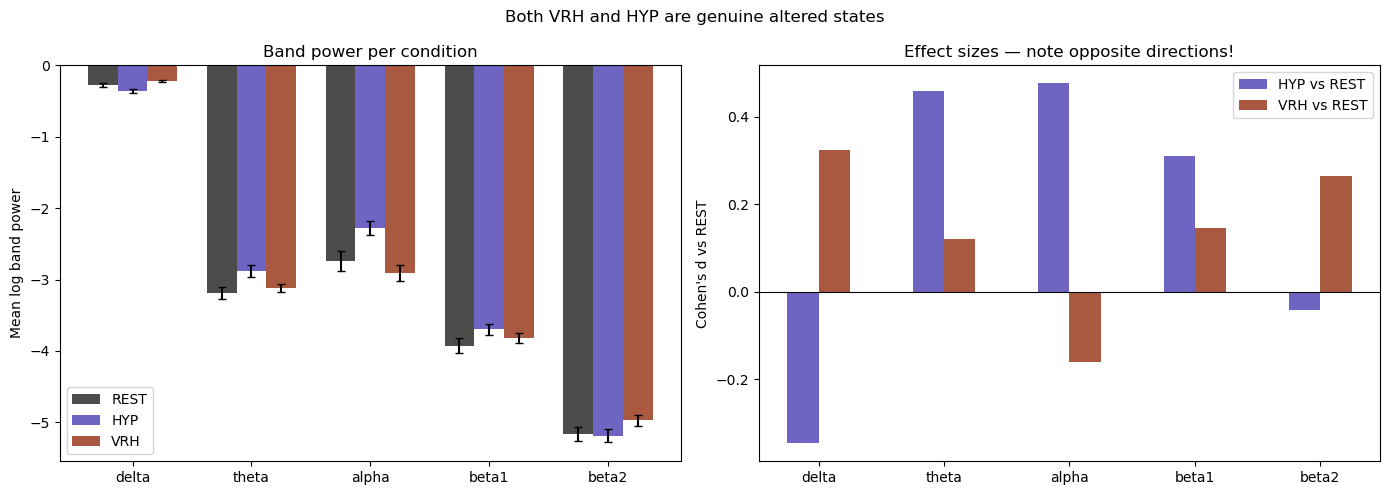

In [5]:
# CELL 3 — Statistical Validation: Are Both States Real?
# ──────────────────────────────────────────────────────────────

def cohens_d(a, b):
    n1, n2 = len(a), len(b)
    pooled = np.sqrt(((n1-1)*a.var(ddof=1) +
                      (n2-1)*b.var(ddof=1)) / (n1+n2-2))
    return (a.mean() - b.mean()) / (pooled + 1e-8)

log_bp = np.log(all_bpower + 1e-8)

def paired_table(idx_a, idx_b, label_a, label_b):
    print(f'\nPaired t-test: {label_b} vs {label_a}')
    print(f'{"Band":8s}  {label_a:>10}  {label_b:>10}  '
          f'{"t":>7}  {"p":>8}  {"d":>8}  {"":>4}')
    print('─'*60)
    for b, band in enumerate(BAND_NAMES):
        a_v = log_bp[y==idx_a, b, :].mean(axis=1)
        b_v = log_bp[y==idx_b, b, :].mean(axis=1)
        t, p = stats.ttest_rel(b_v, a_v)
        d    = cohens_d(b_v, a_v)
        sig  = '★' if p<0.05 else ('~' if p<0.10 else '')
        print(f'{band:8s}  {a_v.mean():>10.3f}  {b_v.mean():>10.3f}  '
              f'{t:>7.3f}  {p:>8.4f}  {d:>8.4f}  {sig}')

paired_table(0, 2, 'REST', 'VRH')
paired_table(0, 1, 'REST', 'HYP')
paired_table(1, 2, 'HYP',  'VRH')

# ── visualise ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

means = {c: log_bp[y==i].mean(axis=(0,2))
         for i,c in enumerate(CONDITIONS)}
sems  = {c: log_bp[y==i].mean(axis=2).std(axis=0)/np.sqrt((y==i).sum())
         for i,c in enumerate(CONDITIONS)}

x, w = np.arange(N_BANDS), 0.25
for i,(cond,col) in enumerate(zip(CONDITIONS,[C_REST,C_HYP,C_VRH])):
    axes[0].bar(x+(i-1)*w, means[cond], w,
                yerr=sems[cond], capsize=3,
                label=cond, color=col, alpha=0.85)
axes[0].set_xticks(x); axes[0].set_xticklabels(BAND_NAMES)
axes[0].set_ylabel('Mean log band power')
axes[0].set_title('Band power per condition')
axes[0].legend()

d_hyp = [cohens_d(log_bp[y==1,b,:].mean(axis=1),
                   log_bp[y==0,b,:].mean(axis=1)) for b in range(N_BANDS)]
d_vrh = [cohens_d(log_bp[y==2,b,:].mean(axis=1),
                   log_bp[y==0,b,:].mean(axis=1)) for b in range(N_BANDS)]
axes[1].bar(x-w/2, d_hyp, w, label='HYP vs REST',
            color=C_HYP, alpha=0.85)
axes[1].bar(x+w/2, d_vrh, w, label='VRH vs REST',
            color=C_VRH, alpha=0.85)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_xticks(x); axes[1].set_xticklabels(BAND_NAMES)
axes[1].set_ylabel("Cohen's d vs REST")
axes[1].set_title('Effect sizes — note opposite directions!')
axes[1].legend()

plt.suptitle('Both VRH and HYP are genuine altered states', fontsize=12)
plt.tight_layout()
plt.savefig('fig1_statistical_validation.png', dpi=150)
plt.show()

In [7]:
# CELL 4 — Feature Matrix (3 versions: power / connectivity / both)
# ──────────────────────────────────────────────────────────────

triu_idx  = np.triu_indices(N_CH, k=1)
TOKEN_DIM = N_CH + len(triu_idx[0])   # 127 + 8001 = 8128

def build_tokens(bpower, dwpli):
    tokens = []
    for b in range(N_BANDS):
        power_b = np.log(bpower[b] + 1e-8)
        conn_b  = dwpli[b][triu_idx]
        tokens.append(np.concatenate([power_b, conn_b]))
    return np.stack(tokens)   # (5, 8128)

# full feature matrix — all conditions
X_all_full = np.array([
    build_tokens(all_bpower[i], all_dwpli[i])
    for i in range(len(y))
], dtype=np.float32)

# filter to HYP and VRH only
mask      = (y==1) | (y==2)
X_both    = X_all_full[mask]                        # power + connectivity
y_bin     = (y[mask]==2).astype(np.int64)           # 0=HYP  1=VRH
subjects  = all_subjects[mask]

# power only version
X_power            = X_both.copy()
X_power[:, :, N_CH:] = 0   # zero connectivity

# connectivity only version
X_conn             = X_both.copy()
X_conn[:, :, :N_CH] = 0    # zero power

print(f'Samples     : {len(y_bin)}  (HYP={( y_bin==0).sum()}  VRH={(y_bin==1).sum()})')
print(f'Subjects    : {len(np.unique(subjects))}')
print(f'Token dim   : {TOKEN_DIM}  (power={N_CH}  connectivity={len(triu_idx[0])})')
print(f'\nFeature sets ready:')
print(f'  X_both  : {X_both.shape}   — power + connectivity')
print(f'  X_power : {X_power.shape}  — power only')
print(f'  X_conn  : {X_conn.shape}   — connectivity only')

Samples     : 132  (HYP=66  VRH=66)
Subjects    : 66
Token dim   : 8128  (power=127  connectivity=8001)

Feature sets ready:
  X_both  : (132, 5, 8128)   — power + connectivity
  X_power : (132, 5, 8128)  — power only
  X_conn  : (132, 5, 8128)   — connectivity only


In [8]:
# CELL 4 — Feature Matrix (3 versions: power / connectivity / both)
# ──────────────────────────────────────────────────────────────

triu_idx  = np.triu_indices(N_CH, k=1)
TOKEN_DIM = N_CH + len(triu_idx[0])   # 127 + 8001 = 8128

def build_tokens(bpower, dwpli):
    tokens = []
    for b in range(N_BANDS):
        power_b = np.log(bpower[b] + 1e-8)
        conn_b  = dwpli[b][triu_idx]
        tokens.append(np.concatenate([power_b, conn_b]))
    return np.stack(tokens)   # (5, 8128)

# full feature matrix — all conditions
X_all_full = np.array([
    build_tokens(all_bpower[i], all_dwpli[i])
    for i in range(len(y))
], dtype=np.float32)

# filter to HYP and VRH only
mask      = (y==1) | (y==2)
X_both    = X_all_full[mask]                        # power + connectivity
y_bin     = (y[mask]==2).astype(np.int64)           # 0=HYP  1=VRH
subjects  = all_subjects[mask]

# power only version
X_power            = X_both.copy()
X_power[:, :, N_CH:] = 0   # zero connectivity

# connectivity only version
X_conn             = X_both.copy()
X_conn[:, :, :N_CH] = 0    # zero power

print(f'Samples     : {len(y_bin)}  (HYP={( y_bin==0).sum()}  VRH={(y_bin==1).sum()})')
print(f'Subjects    : {len(np.unique(subjects))}')
print(f'Token dim   : {TOKEN_DIM}  (power={N_CH}  connectivity={len(triu_idx[0])})')
print(f'\nFeature sets ready:')
print(f'  X_both  : {X_both.shape}   — power + connectivity')
print(f'  X_power : {X_power.shape}  — power only')
print(f'  X_conn  : {X_conn.shape}   — connectivity only')

Samples     : 132  (HYP=66  VRH=66)
Subjects    : 66
Token dim   : 8128  (power=127  connectivity=8001)

Feature sets ready:
  X_both  : (132, 5, 8128)   — power + connectivity
  X_power : (132, 5, 8128)  — power only
  X_conn  : (132, 5, 8128)   — connectivity only


In [9]:
# CELL 5 — Model Definitions
# ──────────────────────────────────────────────────────────────

class EEGDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self):         return len(self.y)
    def __getitem__(self, i):  return self.X[i], self.y[i]


class EEGTransformer(nn.Module):
    """
    Transformer encoder for EEG band-token sequences.
    Input  : (batch, n_bands, token_dim)
    Output : (logits, cls_embedding)
    """
    def __init__(self, token_dim=50, d_model=32,
                 nhead=4, n_layers=2,
                 n_classes=2, dropout=0.3):
        super().__init__()
        self.input_proj = nn.Linear(token_dim, d_model)
        self.cls_token  = nn.Parameter(torch.zeros(1,1,d_model))
        self.pos_embed  = nn.Parameter(torch.zeros(1,N_BANDS+1,d_model))
        enc = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead,
            dim_feedforward=64, dropout=dropout,
            batch_first=True)
        self.transformer = nn.TransformerEncoder(enc, num_layers=n_layers)
        self.norm = nn.LayerNorm(d_model)
        self.head = nn.Sequential(nn.Dropout(dropout),
                                   nn.Linear(d_model, n_classes))
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

    def forward(self, x):
        B   = x.size(0)
        x   = self.input_proj(x)
        cls = self.cls_token.expand(B,-1,-1)
        x   = torch.cat([cls,x], dim=1) + self.pos_embed
        x   = self.norm(self.transformer(x))
        cls_out = x[:,0,:]
        return self.head(cls_out), cls_out


class EEGNet(nn.Module):
    """
    EEGNet adapted for band power features.
    Reference: Lawhern et al. (2018).
    Input  : (batch, 1, N_COMP, N_BANDS)
    Output : logits
    """
    def __init__(self, n_bands=5, n_comp=50,
                 n_classes=2, dropout=0.5, F1=8, D=2):
        super().__init__()
        F2 = F1 * D
        self.conv1 = nn.Sequential(
            nn.Conv2d(1, F1, kernel_size=(1,n_bands),
                      padding=(0,n_bands//2), bias=False),
            nn.BatchNorm2d(F1))
        self.conv2 = nn.Sequential(
            nn.Conv2d(F1, F2, kernel_size=(n_comp,1),
                      groups=F1, bias=False),
            nn.BatchNorm2d(F2), nn.ELU(),
            nn.AvgPool2d((1,2)), nn.Dropout(dropout))
        self.conv3 = nn.Sequential(
            nn.Conv2d(F2, F2, kernel_size=(1,3),
                      padding=(0,1), bias=False),
            nn.BatchNorm2d(F2), nn.ELU(),
            nn.AvgPool2d((1,2)), nn.Dropout(dropout))
        self._flat = self._get_flat(n_bands, n_comp)
        self.fc = nn.Linear(self._flat, n_classes)

    def _get_flat(self, n_bands, n_comp):
        with torch.no_grad():
            x = torch.zeros(1,1,n_comp,n_bands)
            return self.conv3(self.conv2(self.conv1(x))).flatten(1).shape[1]

    def forward(self, x):
        return self.fc(self.conv3(self.conv2(self.conv1(x))).flatten(1))


class EEGNetDataset(Dataset):
    def __init__(self, X, y):
        # X: (N, N_BANDS, N_COMP) → (N, 1, N_COMP, N_BANDS)
        X_en = X.transpose(0,2,1)[:,np.newaxis,:,:]
        self.X = torch.tensor(X_en, dtype=torch.float32)
        self.y = torch.tensor(y,    dtype=torch.long)
    def __len__(self):         return len(self.y)
    def __getitem__(self, i):  return self.X[i], self.y[i]


print('EEGTransformer ✓')
print('EEGNet         ✓')

EEGTransformer ✓
EEGNet         ✓


In [10]:
# CELL 6 — LOSO-CV Function (reusable)
# ──────────────────────────────────────────────────────────────

def run_loso_cv(X_input, y_input, subj_input,
                model_type='transformer',
                epochs=200, lr=5e-4,
                patience=15, label=''):
    """
    LOSO cross-validation for EEGTransformer or EEGNet.
    Returns: mean_acc, fold_accs, all_preds, all_true, all_embeds
    """
    fold_accs, all_preds, all_true, all_embeds = [], [], [], []
    unique_s  = np.unique(subj_input)

    for fold, test_subj in enumerate(unique_s):

        tr = subj_input != test_subj
        te = subj_input == test_subj
        X_tr_raw, X_te_raw = X_input[tr], X_input[te]
        y_tr, y_te         = y_input[tr], y_input[te]

        # PCA per band — fit on train only
        X_tr = np.zeros((len(y_tr), N_BANDS, N_COMP), dtype=np.float32)
        X_te = np.zeros((len(y_te), N_BANDS, N_COMP), dtype=np.float32)
        for b in range(N_BANDS):
            band_tr = X_tr_raw[:, b, :]
            if np.allclose(band_tr, 0): continue
            sc  = StandardScaler()
            pca = PCA(n_components=N_COMP, random_state=SEED)
            ts  = sc.fit_transform(band_tr)
            if np.isnan(ts).any() or np.allclose(ts, 0): continue
            X_tr[:, b, :] = pca.fit_transform(ts)
            X_te[:, b, :] = pca.transform(sc.transform(X_te_raw[:,b,:]))

        # build model
        if model_type == 'transformer':
            model    = EEGTransformer(token_dim=N_COMP).to(device)
            train_dl = DataLoader(EEGDataset(X_tr, y_tr),
                                  batch_size=16, shuffle=True)
        else:
            model    = EEGNet(n_bands=N_BANDS, n_comp=N_COMP).to(device)
            train_dl = DataLoader(EEGNetDataset(X_tr, y_tr),
                                  batch_size=16, shuffle=True)

        opt   = torch.optim.AdamW(model.parameters(),
                                   lr=lr, weight_decay=1e-2)
        sched = torch.optim.lr_scheduler.CosineAnnealingLR(
                    opt, T_max=epochs)
        crit  = nn.CrossEntropyLoss()

        best_loss, best_state, wait = float('inf'), None, 0
        model.train()
        for epoch in range(epochs):
            ep_loss = 0
            for xb, yb in train_dl:
                xb, yb = xb.to(device), yb.to(device)
                opt.zero_grad()
                out = model(xb)
                logits = out[0] if isinstance(out, tuple) else out
                loss = crit(logits, yb)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                opt.step()
                ep_loss += loss.item()
            sched.step()
            avg = ep_loss / len(train_dl)
            if avg < best_loss - 1e-4:
                best_loss  = avg
                best_state = {k: v.clone()
                              for k, v in model.state_dict().items()}
                wait = 0
            else:
                wait += 1
                if wait >= patience: break

        if best_state:
            model.load_state_dict(best_state)

        model.eval()
        with torch.no_grad():
            if model_type == 'transformer':
                xt = torch.tensor(X_te,
                                  dtype=torch.float32).to(device)
                logits, embeds = model(xt)
            else:
                xt = torch.tensor(
                         X_te.transpose(0,2,1)[:,np.newaxis,:,:],
                         dtype=torch.float32).to(device)
                logits = model(xt)
                embeds = torch.zeros(len(y_te), 1)
            preds = logits.argmax(dim=1).cpu().numpy()

        fold_accs.append((preds == y_te).mean())
        all_preds.append(preds)
        all_true.append(y_te)
        all_embeds.append(embeds.cpu().numpy())

        if (fold+1) % 10 == 0 or fold == 0:
            print(f'  {fold+1:2d}/{len(unique_s)}  '
                  f'mean acc: {np.mean(fold_accs):.3f}')

    all_preds  = np.concatenate(all_preds)
    all_true   = np.concatenate(all_true)
    all_embeds = np.concatenate(all_embeds)
    mean_acc   = np.mean(fold_accs)
    bt         = binomtest(int(mean_acc*len(all_true)),
                            len(all_true), 0.5,
                            alternative='greater')
    if label:
        sig = '★' if bt.pvalue<0.05 else '~' if bt.pvalue<0.10 else ''
        print(f'\n{label:30s}: {mean_acc:.3f} ± '
              f'{np.std(fold_accs):.3f}  '
              f'p={bt.pvalue:.4f} {sig}')

    return mean_acc, fold_accs, all_preds, all_true, all_embeds

print('run_loso_cv() defined ✓')

run_loso_cv() defined ✓


In [11]:
# CELL 7 — Run All Feature Configurations (~45 mins total)
# ──────────────────────────────────────────────────────────────
# Coffee time ☕ — 3 x ~15 mins

print('='*55)
print('FEATURE COMPARISON — 66 subjects')
print('='*55)

# 1 — power + connectivity (combined)
print('\n[1/3] Power + Connectivity...')
acc_both, fa_both, pred_both, true_both, emb_both = run_loso_cv(
    X_both, y_bin, subjects,
    model_type='transformer',
    label='Transformer (both)        ')

# 2 — power only
print('\n[2/3] Power only...')
acc_pow, fa_pow, pred_pow, true_pow, emb_pow = run_loso_cv(
    X_power, y_bin, subjects,
    model_type='transformer',
    label='Transformer (power only)  ')

# 3 — connectivity only
print('\n[3/3] Connectivity only...')
acc_con, fa_con, pred_con, true_con, emb_con = run_loso_cv(
    X_conn, y_bin, subjects,
    model_type='transformer',
    label='Transformer (conn only)   ')

# pick best
accs        = [acc_both, acc_pow, acc_con]
names       = ['both', 'power', 'connectivity']
best_idx    = int(np.argmax(accs))
best_name   = names[best_idx]
best_acc    = accs[best_idx]

# set best as main result
if best_idx == 0:
    X_best, mean_acc, fold_accs = X_both,  acc_both, fa_both
    all_preds, all_true, all_embeddings = pred_both, true_both, emb_both
elif best_idx == 1:
    X_best, mean_acc, fold_accs = X_power, acc_pow,  fa_pow
    all_preds, all_true, all_embeddings = pred_pow,  true_pow,  emb_pow
else:
    X_best, mean_acc, fold_accs = X_conn,  acc_con,  fa_con
    all_preds, all_true, all_embeddings = pred_con,  true_con,  emb_con

btest = binomtest(int(mean_acc*len(all_true)),
                   len(all_true), 0.5, alternative='greater')

print(f'\n{"="*55}')
print(f'RESULTS SUMMARY')
print(f'{"="*55}')
print(f'Power + Connectivity : {acc_both:.3f}')
print(f'Power only           : {acc_pow:.3f}')
print(f'Connectivity only    : {acc_con:.3f}')
print(f'Chance               : 0.500')
print(f'\n→ Best: {best_name} ({best_acc:.3f})')
print(f'  p-value : {btest.pvalue:.4f} '
      f'{"★" if btest.pvalue<0.05 else "~ trend" if btest.pvalue<0.10 else ""}')
print(f'\nClassification report (best config):')
print(classification_report(all_true, all_preds,
      target_names=['HYP','VRH']))

FEATURE COMPARISON — 66 subjects

[1/3] Power + Connectivity...
   1/66  mean acc: 0.500
  10/66  mean acc: 0.600
  20/66  mean acc: 0.650
  30/66  mean acc: 0.583
  40/66  mean acc: 0.613
  50/66  mean acc: 0.600
  60/66  mean acc: 0.567

Transformer (both)            : 0.561 ± 0.295  p=0.0957 ~

[2/3] Power only...
   1/66  mean acc: 1.000
  10/66  mean acc: 0.700
  20/66  mean acc: 0.525
  30/66  mean acc: 0.500
  40/66  mean acc: 0.500
  50/66  mean acc: 0.550
  60/66  mean acc: 0.542

Transformer (power only)      : 0.523 ± 0.342  p=0.3318 

[3/3] Connectivity only...
   1/66  mean acc: 0.500
  10/66  mean acc: 0.500
  20/66  mean acc: 0.525
  30/66  mean acc: 0.500
  40/66  mean acc: 0.475
  50/66  mean acc: 0.500
  60/66  mean acc: 0.500

Transformer (conn only)       : 0.508 ± 0.320  p=0.4653 

RESULTS SUMMARY
Power + Connectivity : 0.561
Power only           : 0.523
Connectivity only    : 0.508
Chance               : 0.500

→ Best: both (0.561)
  p-value : 0.0957 ~ trend

Clas

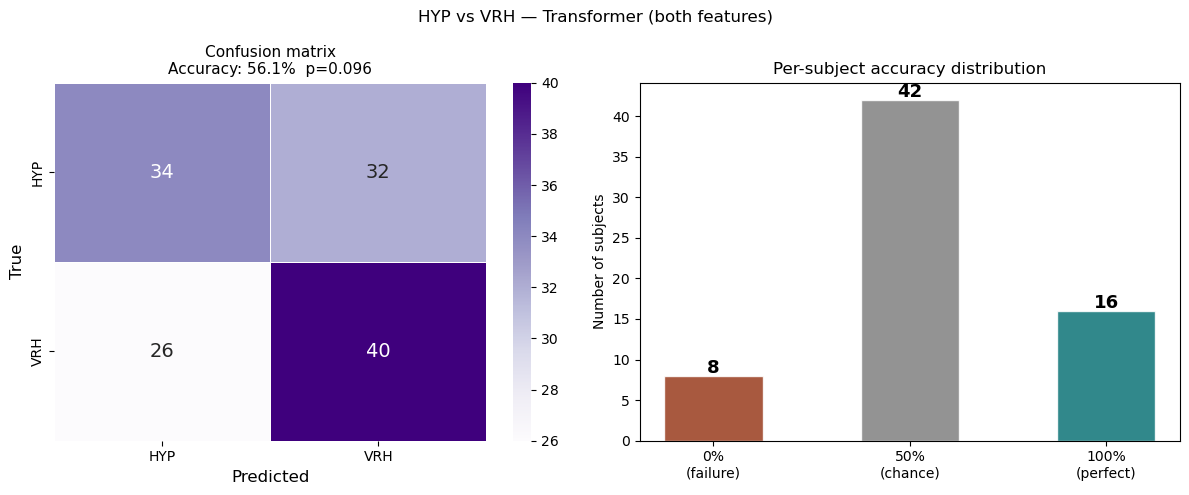


Per-subject breakdown:
  Subj            True            Pred    Acc
────────────────────────────────────────────────
S   1  ['HYP', 'VRH']  ['HYP', 'HYP']  0.50
S   2  ['HYP', 'VRH']  ['HYP', 'VRH']  1.00
S   3  ['HYP', 'VRH']  ['VRH', 'VRH']  0.50
S   4  ['HYP', 'VRH']  ['HYP', 'VRH']  1.00
S   5  ['HYP', 'VRH']  ['VRH', 'HYP']  0.00
S   6  ['HYP', 'VRH']  ['VRH', 'VRH']  0.50
S   7  ['HYP', 'VRH']  ['VRH', 'VRH']  0.50
S   8  ['HYP', 'VRH']  ['VRH', 'VRH']  0.50
S   9  ['HYP', 'VRH']  ['VRH', 'VRH']  0.50
S  10  ['HYP', 'VRH']  ['HYP', 'VRH']  1.00
S  11  ['HYP', 'VRH']  ['HYP', 'VRH']  1.00
S  12  ['HYP', 'VRH']  ['HYP', 'VRH']  1.00
S  13  ['HYP', 'VRH']  ['HYP', 'HYP']  0.50
S  14  ['HYP', 'VRH']  ['VRH', 'VRH']  0.50
S  15  ['HYP', 'VRH']  ['HYP', 'VRH']  1.00
S  16  ['HYP', 'VRH']  ['VRH', 'VRH']  0.50
S  17  ['HYP', 'VRH']  ['HYP', 'VRH']  1.00
S  18  ['HYP', 'VRH']  ['VRH', 'HYP']  0.00
S  19  ['HYP', 'VRH']  ['HYP', 'HYP']  0.50
S  20  ['HYP', 'VRH']  ['HYP', 'VRH']  1.00
S

In [12]:
# CELL 8 — Confusion Matrix + Per-subject Breakdown
# ──────────────────────────────────────────────────────────────

unique_subjs = np.unique(subjects)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm = confusion_matrix(all_true, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['HYP','VRH'],
            yticklabels=['HYP','VRH'],
            ax=axes[0], linewidths=0.5,
            annot_kws={'size':14})
axes[0].set_xlabel('Predicted', fontsize=12)
axes[0].set_ylabel('True', fontsize=12)
axes[0].set_title(f'Confusion matrix\n'
                  f'Accuracy: {mean_acc:.1%}  '
                  f'p={btest.pvalue:.3f}', fontsize=11)

dist = {
    '0%\n(failure)' : sum(a==0.0 for a in fold_accs),
    '50%\n(chance)' : sum(a==0.5 for a in fold_accs),
    '100%\n(perfect)': sum(a==1.0 for a in fold_accs),
}
bars = axes[1].bar(dist.keys(), dist.values(),
                   color=[C_VRH,'gray',C_SHARED],
                   alpha=0.85, edgecolor='white', width=0.5)
axes[1].set_ylabel('Number of subjects')
axes[1].set_title('Per-subject accuracy distribution')
for bar, val in zip(bars, dist.values()):
    axes[1].text(bar.get_x()+bar.get_width()/2,
                 val+0.3, str(val),
                 ha='center', fontsize=13, fontweight='bold')

plt.suptitle(f'HYP vs VRH — Transformer ({best_name} features)',
             fontsize=12)
plt.tight_layout()
plt.savefig('fig2_confusion_matrix.png', dpi=150)
plt.show()

# per-subject table
print(f'\nPer-subject breakdown:')
print(f'{"Subj":>6}  {"True":>14}  {"Pred":>14}  {"Acc":>5}')
print('─'*48)
start = 0
for fold, subj in enumerate(unique_subjs):
    n = (subjects==subj).sum()
    ts = all_true[start:start+n]
    ps = all_preds[start:start+n]
    tn = ['HYP' if t==0 else 'VRH' for t in ts]
    pn = ['HYP' if p==0 else 'VRH' for p in ps]
    print(f'S{subj:>4}  {str(tn):>14}  {str(pn):>14}  '
          f'{fold_accs[fold]:.2f}')
    start += n

Running EEGNet with best feature set...

   1/66  mean acc: 0.500
  10/66  mean acc: 0.450
  20/66  mean acc: 0.525
  30/66  mean acc: 0.533
  40/66  mean acc: 0.537
  50/66  mean acc: 0.520
  60/66  mean acc: 0.533

EEGNet (best features)        : 0.553 ± 0.263  p=0.1289 


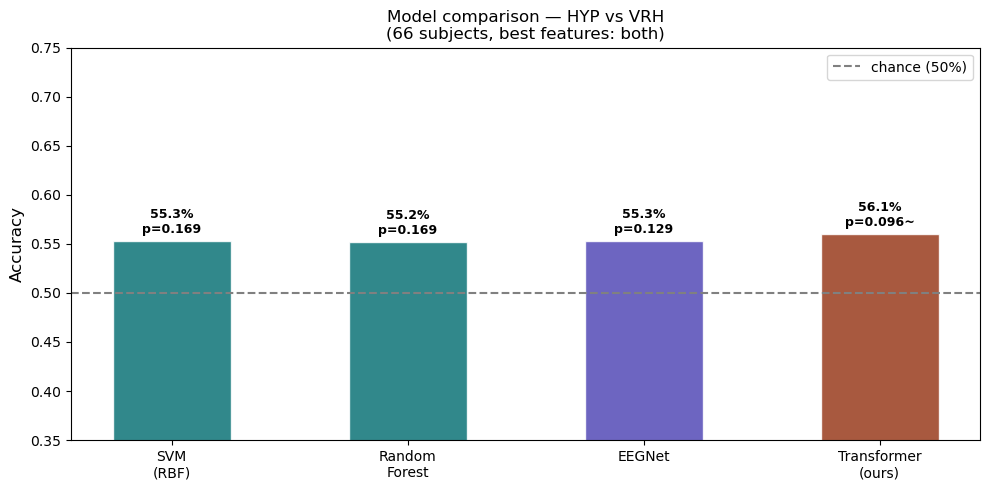


Model comparison:
──────────────────────────────────────────────────
  SVM (RBF)             : 0.553  p=0.1692 
  Random Forest         : 0.552  p=0.1692 
  EEGNet                : 0.553  p=0.1289 
  Transformer (ours)    : 0.561  p=0.0957 ~


In [13]:
# CELL 9 — EEGNet Comparison (~15 mins)
# ──────────────────────────────────────────────────────────────

print('Running EEGNet with best feature set...\n')

acc_eegnet, fa_en, pred_en, true_en, _ = run_loso_cv(
    X_best, y_bin, subjects,
    model_type = 'eegnet',
    label      = 'EEGNet (best features)    '
)

bt_en = binomtest(int(acc_eegnet*len(true_en)),
                   len(true_en), 0.5, alternative='greater')

# SVM baseline
X_flat = X_best.reshape(len(y_bin), -1)
cv5    = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
pipe   = Pipeline([('sc',StandardScaler()),
                   ('clf',SVC(kernel='rbf',C=1.0,random_state=SEED))])
svm_scores = cross_val_score(pipe, X_flat, y_bin,
                              cv=cv5, scoring='accuracy')
acc_svm = svm_scores.mean()

# RF baseline
pipe_rf    = Pipeline([('sc',StandardScaler()),
                        ('clf',RandomForestClassifier(
                            n_estimators=200,random_state=SEED))])
rf_scores  = cross_val_score(pipe_rf, X_flat, y_bin,
                               cv=cv5, scoring='accuracy')
acc_rf = rf_scores.mean()

# ── model comparison figure ───────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

model_names = ['SVM\n(RBF)', 'Random\nForest',
               'EEGNet', 'Transformer\n(ours)']
model_accs  = [acc_svm, acc_rf, acc_eegnet, mean_acc]
model_cols  = [C_SHARED, C_SHARED, C_HYP, C_VRH]

bt_svm = binomtest(int(acc_svm*len(y_bin)),
                    len(y_bin), 0.5, alternative='greater')
bt_rf  = binomtest(int(acc_rf*len(y_bin)),
                    len(y_bin), 0.5, alternative='greater')

p_vals = [bt_svm.pvalue, bt_rf.pvalue,
          bt_en.pvalue,  btest.pvalue]

bars = ax.bar(model_names, model_accs,
              color=model_cols, alpha=0.85,
              edgecolor='white', width=0.5)
ax.axhline(0.5, color='gray', linestyle='--',
           linewidth=1.5, label='chance (50%)')
ax.set_ylim(0.35, 0.75)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title(f'Model comparison — HYP vs VRH\n'
             f'({len(np.unique(subjects))} subjects, '
             f'best features: {best_name})', fontsize=12)
ax.legend(fontsize=10)

for bar, val, p in zip(bars, model_accs, p_vals):
    sig = '★' if p<0.05 else '~' if p<0.10 else ''
    ax.text(bar.get_x()+bar.get_width()/2,
            val+0.008,
            f'{val:.1%}\np={p:.3f}{sig}',
            ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('fig3_model_comparison.png', dpi=150)
plt.show()

print(f'\nModel comparison:')
print(f'{"─"*50}')
for n, a, p in zip(model_names, model_accs, p_vals):
    n_clean = n.replace('\n',' ')
    print(f'  {n_clean:22s}: {a:.3f}  p={p:.4f} '
          f'{"★" if p<0.05 else "~" if p<0.10 else ""}')

In [1]:
# CELL 10 — Permutation Test (~5 mins)
# ──────────────────────────────────────────────────────────────

N_PERMS   = 1000
perm_accs = []

print(f'Running permutation test ({N_PERMS} shuffles)...')

X_flat_perm = X_best.reshape(len(y_bin), -1)
perm_pipe   = Pipeline([('sc',StandardScaler()),
                         ('clf',SVC(kernel='rbf',C=1.0,
                                    random_state=SEED))])

for i in range(N_PERMS):
    y_shuf  = np.random.permutation(y_bin)
    cv_perm = StratifiedKFold(n_splits=5, shuffle=True,
                               random_state=i)
    sc = cross_val_score(perm_pipe, X_flat_perm,
                          y_shuf, cv=cv_perm,
                          scoring='accuracy')
    perm_accs.append(sc.mean())
    if (i+1) % 200 == 0:
        print(f'  {i+1}/{N_PERMS} done...')

perm_accs   = np.array(perm_accs)
perm_p      = (perm_accs >= mean_acc).mean()
perm_p_svm  = (perm_accs >= acc_svm).mean()

print(f'\nNull distribution:')
print(f'  Mean  : {perm_accs.mean():.3f}')
print(f'  95th %: {np.percentile(perm_accs,95):.3f}')
print(f'\nPermutation p-values:')
print(f'  Transformer : {mean_acc:.3f}  '
      f'p={perm_p:.4f} '
      f'{"★" if perm_p<0.05 else "~ trend" if perm_p<0.10 else ""}')
print(f'  SVM         : {acc_svm:.3f}  '
      f'p={perm_p_svm:.4f} '
      f'{"★" if perm_p_svm<0.05 else "~ trend" if perm_p_svm<0.10 else ""}')

fig, ax = plt.subplots(figsize=(9,5))
ax.hist(perm_accs, bins=40, color=C_SHARED,
        alpha=0.7, edgecolor='white',
        label=f'Null distribution ({N_PERMS} shuffles)')
ax.axvline(mean_acc, color=C_VRH, linewidth=2.5,
           label=f'Transformer: {mean_acc:.3f} (p={perm_p:.3f})')
ax.axvline(acc_svm, color=C_HYP, linewidth=2,
           linestyle='--',
           label=f'SVM: {acc_svm:.3f} (p={perm_p_svm:.3f})')
p95 = np.percentile(perm_accs, 95)
ax.axvline(p95, color='gray', linewidth=1.5,
           linestyle=':',
           label=f'95th percentile: {p95:.3f}')
ax.set_xlabel('Accuracy under null hypothesis', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.set_title('Permutation test — HYP vs VRH\n'
             'Is our accuracy above the null distribution?',
             fontsize=12)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('fig4_permutation_test.png', dpi=150)
plt.show()

Running permutation test (1000 shuffles)...


NameError: name 'X_best' is not defined